## Task 1

In [1]:
import numpy as np
import torch as T
import sklearn
import matplotlib.pyplot as plt

In [2]:
device = T.device("cuda" if T.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
data = sklearn.datasets.fetch_california_housing()
X_np = data["data"].astype(np.float32)
y_np = data["target"].astype(np.float32)

In [4]:
N, d = X_np.shape

In [5]:
X_train_np, X_test_np, y_train_np, y_test_np = sklearn.model_selection.train_test_split(
    X_np, y_np, test_size=0.2, random_state=42
)

In [6]:
X_train = T.from_numpy(X_train_np)
X_test  = T.from_numpy(X_test_np)
y_train = T.from_numpy(y_train_np).view(-1, 1)
y_test  = T.from_numpy(y_test_np).view(-1, 1)

In [7]:
mu = X_train.mean(dim=0, keepdim=True)
sigma = X_train.std(dim=0, keepdim=True)
mu, sigma

(tensor([[ 3.8808e+00,  2.8608e+01,  5.4352e+00,  1.0967e+00,  1.4265e+03,
           3.0970e+00,  3.5643e+01, -1.1958e+02]]),
 tensor([[1.9043e+00, 1.2602e+01, 2.3874e+00, 4.3321e-01, 1.1371e+03, 1.1579e+01,
          2.1367e+00, 2.0057e+00]]))

In [8]:
X_train = (X_train - mu) / sigma
X_test  = (X_test  - mu) / sigma

In [9]:
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

W = T.randn(d, 1, requires_grad=True, device=device)
b = T.randn(1, requires_grad=True, device=device)

def forward(X):
    return X @ W + b

def mse_loss(y_hat, y):
    return ((y_hat - y) ** 2).mean()

lr = 0.05
epochs = 400

train_losses = []
test_losses = []
for epoch in range(epochs):
    y_hat_train = forward(X_train)
    loss_train = mse_loss(y_hat_train, y_train)

    loss_train.backward()
    with T.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

    W.grad.zero_()
    b.grad.zero_()

    with T.no_grad():
        y_hat_test = forward(X_test)
        loss_val = mse_loss(y_hat_test, y_test)

    train_losses.append(loss_train.item())
    test_losses.append(loss_val.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | train loss: {train_losses[-1]:.4f} | test loss: {test_losses[-1]:.4f}")

Epoch   50 | train loss: 0.7541 | test loss: 0.7828
Epoch  100 | train loss: 0.6250 | test loss: 0.6329
Epoch  150 | train loss: 0.5673 | test loss: 0.5742
Epoch  200 | train loss: 0.5412 | test loss: 0.5529
Epoch  250 | train loss: 0.5291 | test loss: 0.5466
Epoch  300 | train loss: 0.5235 | test loss: 0.5461
Epoch  350 | train loss: 0.5208 | test loss: 0.5474
Epoch  400 | train loss: 0.5194 | test loss: 0.5491


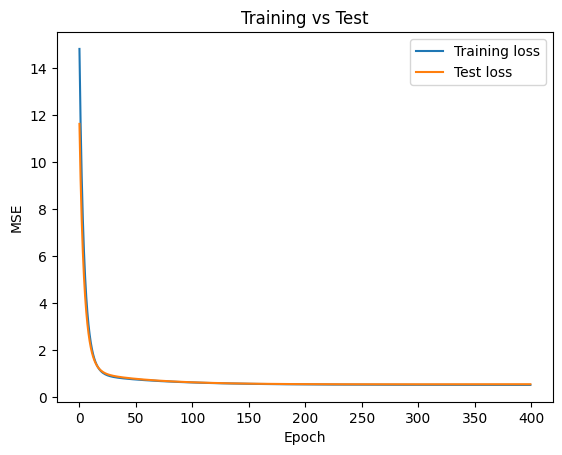

In [10]:
plt.figure()
plt.plot(train_losses, label="Training loss")
plt.plot(test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Test")
plt.legend()
plt.show()

### Why do we need `torch.no_grad` during parameter update?
The operations would normally track to build the computation graph for autograd.
Parameter update is not the forward computation.

### Why must we reset gradients each iteration?
Torch gradients accumulate by default. Having old gradient would overflow the update.

## Task 2

In [11]:
ones_train = T.ones((X_train.shape[0], 1), device=device)
# ones_test  = T.ones((X_test.shape[0], 1), device=device)

In [12]:
X_train_aug = T.cat([X_train, ones_train], dim=1)
# X_test_aug  = T.cat([X_test, ones_test], dim=1)

In [13]:
Wb_star = T.linalg.pinv(X_train_aug) @ y_train
Wb_star
W_star, b_star = Wb_star[:-1, :], Wb_star[-1, :]

In [14]:
W_star, b_star

(tensor([[ 0.8544],
         [ 0.1225],
         [-0.2944],
         [ 0.3393],
         [-0.0023],
         [-0.0408],
         [-0.8970],
         [-0.8699]], device='cuda:0'),
 tensor([2.0720], device='cuda:0'))

In [15]:
y_pred = X_train @ W_star + b_star
loss = ((y_pred - y_train)**2).mean()
loss

tensor(0.5179, device='cuda:0')

In [18]:
with T.no_grad():
    train_cf = ((X_train @ W_star + b_star - y_train)**2).mean()
    test_cf = ((X_test @ W_star + b_star - y_test)**2).mean()

    train_gd = ((X_train @ W + b - y_train)**2).mean()
    test_gd = ((X_test @ W + b - y_test)**2).mean()

    print("GD train/test:", train_gd.item(), test_gd.item())
    print("CF train/test:", train_cf.item(), test_cf.item())

GD train/test: 0.5194035172462463 0.5491355657577515
CF train/test: 0.5179330706596375 0.5558915138244629


### Comparison
The gradient decent method got better results at test set but is worse at training one.
Closed form found the best solution in the training set.

### When is the closed-form solution feasible, and when it is not?
Is feasible when:
- the number of features $d$ is small (the time complexity of `pinv` is $O(Nd^2)$
- you can manimulate matrices like $X^TX$
- computation is acceptable (if you can store $N\times d$ matrix in memory)

### Why might gradient decent not match the closed-form result exactly (even on oconvex problems)?
- fixed number of epochs -> gradient decent stop before converging
- wrong learning rate?
- float precision

## Bonus Task

### Part A

In [34]:
X_raw = T.from_numpy(X_np).to(device)
y = T.from_numpy(y_np).to(device)

mu = X_raw.mean(dim=0, keepdim=True)
sigma = X_raw.std(dim=0, keepdim=True)
mu, sigma

X_norm = (X_raw - mu) / sigma

def kappa(X):
    evals = T.linalg.eigvalsh(X.T @ X)
    lam_min = evals.min().item()
    lam_max = evals.max().item()
    return lam_max / lam_min

print(f"Raw features kappa: ", kappa(X_raw))
print(f"Norm features kappa: ", kappa(X_norm))

Raw features kappa:  112566640.34143479
Norm features kappa:  44.465296224024435


#### Is the condition number larger without normalization?
$\kappa$ is much larger for raw features than normalized.
Normalization reduced scale difference between columns.
#### What does a large condition number indicate?
Large $\kappa$ means very different curvature in different directions. Gradient will zig-zag. Numberical errors can cause problems.
#### What happens is $\lambda_{min} \approx 0$?
The inverse of $(X^TX)$ is unstable or doesn't exist. Some directions with no curvature (redundant features). Unstable solutions

### Part B

torch.Size([20640, 9])
torch.Size([9])


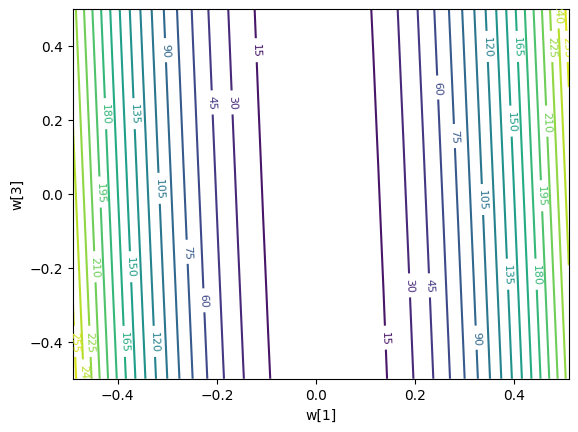

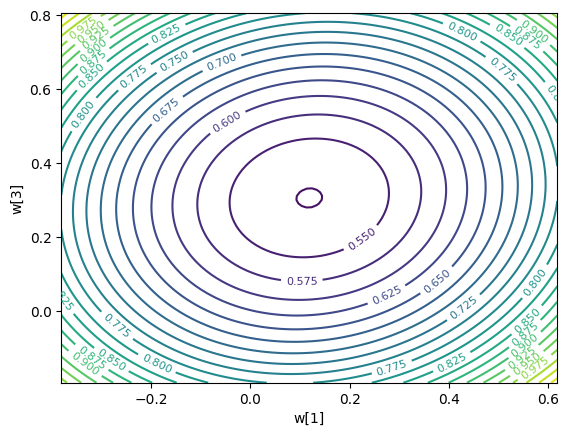

In [41]:
def plot_contour_loss(X, y, W, i, j, steps=100):
    Z = T.empty((steps, steps))

    wi = T.linspace(W[i].item() - 0.5, W[i].item() + 0.5, steps)
    wj = T.linspace(W[j].item() - 0.5, W[j].item() + 0.5, steps)
    
    for a in range(steps):
        for b in range(steps):
            W_ = W.clone()
            W_[i] = wi[a]
            W_[j] = wj[b]
            Z[a, b] = ((X @ W_ - y)**2).mean()

    plt.figure()
    cs = plt.contour(wi, wj, Z.T, levels=25)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.xlabel(f"w[{i}]")
    plt.ylabel(f"w[{j}]")
    plt.show()

X_raw = T.from_numpy(X_np).to(device)
y = T.from_numpy(y_np).to(device)

mu = X_raw.mean(dim=0, keepdim=True)
sigma = X_raw.std(dim=0, keepdim=True)
mu, sigma

X_norm = (X_raw - mu) / sigma

X_raw = T.cat([X_raw, T.ones((X_raw.shape[0], 1), device=device)], dim=1)
X_norm = T.cat([X_norm, T.ones((X_norm.shape[0], 1), device=device)], dim=1)

W_raw_star = T.linalg.pinv(X_raw) @ y
W_norm_star = T.linalg.pinv(X_norm) @ y

print(X_raw.shape)
print(W_raw_star.shape)

plot_contour_loss(X_raw, y, W_raw_star, 1, 3)
plot_contour_loss(X_norm, y, W_norm_star, 1, 3)

#### What is the shape of the contours without the normalization?
They are verical.
#### What is the shape after normalization?
It is nicely round.
#### Are they circular or elongated?
Without normalization they are elongated, with normalization circular.
#### How does this relate to the condition number?
Given that the loss function is convex the condition number compares the 
fastest growing direction and slowest growing direction. After normalization those values are close to each other giving nice and circular shape.

## Task 3

For lr=0.01 loss: 0.5504095554351807
For lr=0.1 loss: 0.5558914542198181
For lr=0.5 loss: inf


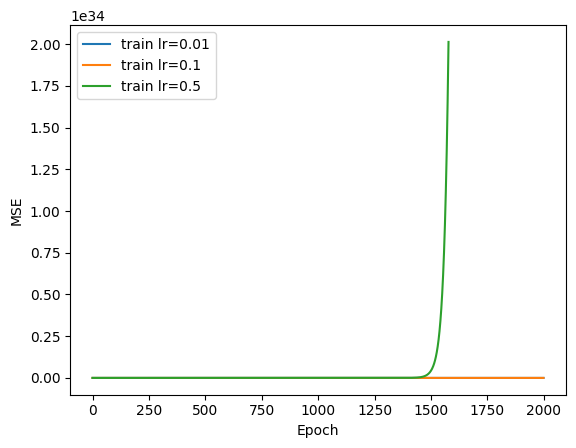

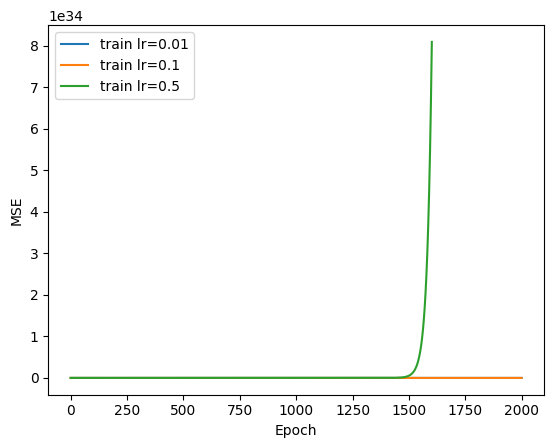

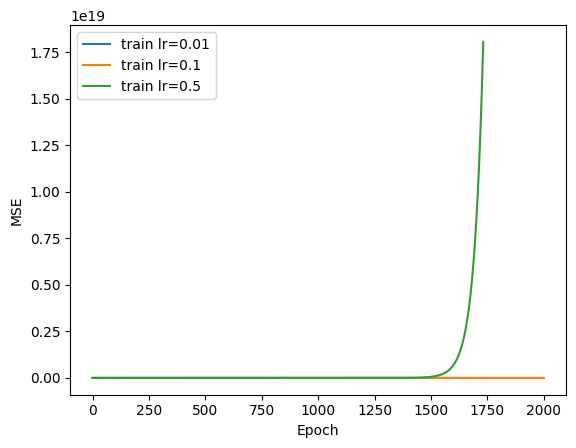

In [73]:
def train_one_lr(lr, W_init, b_init, epochs=2000):
    W = W_init.detach().clone().requires_grad_(True).to(device)
    b = b_init.detach().clone().requires_grad_(True).to(device)
    
    train_losses, test_losses, grad_norms = [], [], []

    for epoch in range(epochs):
        y_hat = X_train @ W + b
        loss = ((y_train - y_hat)**2).mean()
        loss.backward()


        with T.no_grad():
            W -= lr * W.grad
            b -= lr * b.grad
            
            gnorm = T.norm(W.grad, p=2).item()

        W.grad.zero_()
        b.grad.zero_()

        with T.no_grad():
            y_hat = X_test @ W + b
            loss_test = ((y_test - y_hat)**2).mean()

        train_losses.append(loss.item())
        test_losses.append(loss_test.item())
        grad_norms.append(gnorm)
    print(f"For lr={lr} loss: {test_losses[-1]}")
    return train_losses, test_losses, grad_norms

lrs = [0.01, 0.1, 0.5]
W_init = T.randn(d, 1, requires_grad=True, device=device)
b_init = T.randn(1, requires_grad=True, device=device)

results = {}
for lr in lrs:
    train_l, test_l, grad_n = train_one_lr(lr, W_init, b_init)
    results[lr] = {
        "train_losses": train_l,
        "test_losses": test_l,
        "grad_norms": grad_n
    }

plt.figure()
for lr in lrs:
    plt.plot(results[lr]["train_losses"], label=f"train lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure()
for lr in lrs:
    plt.plot(results[lr]["test_losses"], label=f"train lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure()
for lr in lrs:
    plt.plot(results[lr]["grad_norms"], label=f"train lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

#### What does divergence look line in the loss curve?
It looks like exponential function.
#### Explain why too-large learning rate causes instability.
If learning rate is too large, the update step "overshoots" the minimum in directions where the loss curvature is steep. The gradient is rapidly changing. Repeating create oscilation and blow up.
#### How does normalizatoin affect the range of "reasonable" learning rate?
- reduces condition number
- convergence tends to be faster and less zig-zag
- some directions are extremely steep and small learning rate avoids overshooting